In [1]:
# install the one library colab doesnt have
!pip install ydata-profiling -q

# core libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3
import warnings
warnings.filterwarnings('ignore')

# machine learning
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import LabelEncoder

# styling — makes all charts look clean
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

print("All libraries loaded ✓")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.8/400.8 kB 9.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 21.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 64.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 679.7/679.7 kB 38.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.4/105.4 kB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.0/72.0 kB 4.7 MB/s eta 0:00:00
All libraries loaded ✓


## Step 1: Data Loading

In [2]:
df = pd.read_csv('/content/bank-full.csv', sep=';')
df

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45206,51,technician,married,tertiary,no,825,no,no,cellular,17,nov,977,3,-1,0,unknown,yes
45207,71,retired,divorced,primary,no,1729,no,no,cellular,17,nov,456,2,-1,0,unknown,yes
45208,72,retired,married,secondary,no,5715,no,no,cellular,17,nov,1127,5,184,3,success,yes
45209,57,blue-collar,married,secondary,no,668,no,no,telephone,17,nov,508,4,-1,0,unknown,no


## Step 2: Data Cleaning

In [3]:
print("=" * 50)
print("DATA AUDIT REPORT")
print("=" * 50)

print(f"\n1. SHAPE: {df.shape[0]:,} rows × {df.shape[1]} columns")

print(f"\n2. DATA TYPES:")
print(df.dtypes)

print(f"\n3. NULL VALUES:")
nulls = df.isnull().sum()
print(nulls[nulls > 0] if nulls.sum() > 0 else "No nulls found ✓")

print(f"\n4. UNKNOWN VALUES (missing data in disguise):")
for col in df.select_dtypes('object').columns:
    unknown_count = (df[col] == 'unknown').sum()
    if unknown_count > 0:
        pct = round(unknown_count / len(df) * 100, 2)
        print(f"   {col}: {unknown_count:,} unknowns ({pct}%)")

print(f"\n5. TARGET VARIABLE (y) DISTRIBUTION:")
print(df['y'].value_counts())

DATA AUDIT REPORT

1. SHAPE: 45,211 rows × 17 columns

2. DATA TYPES:
age           int64
job          object
marital      object
education    object
default      object
balance       int64
housing      object
loan         object
contact      object
day           int64
month        object
duration      int64
campaign      int64
pdays         int64
previous      int64
poutcome     object
y            object
dtype: object

3. NULL VALUES:
No nulls found ✓

4. UNKNOWN VALUES (missing data in disguise):
   job: 288 unknowns (0.64%)
   education: 1,857 unknowns (4.11%)
   contact: 13,020 unknowns (28.8%)
   poutcome: 36,959 unknowns (81.75%)

5. TARGET VARIABLE (y) DISTRIBUTION:
y
no     39922
yes     5289
Name: count, dtype: int64


In [4]:
# make a copy — never modify the original
df_clean = df.copy()

# DECISION 1: convert target to binary
# 'yes' → 1, 'no' → 0 — needed for model later
df_clean['y_binary'] = (df_clean['y'] == 'yes').astype(int)

# DECISION 3: create duration in minutes (more readable than seconds)
df_clean['duration_min'] = df_clean['duration'] / 60

# DECISION 4: create age groups for segmentation
df_clean['age_group'] = pd.cut(
    df_clean['age'],
    bins=[0, 25, 35, 45, 55, 65, 100],
    labels=['18-25', '26-35', '36-45', '46-55', '56-65', '65+']
)

# confirm clean
print(f"Clean dataframe shape: {df_clean.shape}")
print(f"\nNew columns added: {[c for c in df_clean.columns if c not in df.columns]}")
print(f"\nTarget distribution:\n{df_clean['y_binary'].value_counts()}")
print(f"\nData cleaning complete ✓")

Clean dataframe shape: (45211, 20)

New columns added: ['y_binary', 'duration_min', 'age_group']

Target distribution:
y_binary
0    39922
1     5289
Name: count, dtype: int64

Data cleaning complete ✓


In [5]:
df_clean

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y,y_binary,duration_min,age_group
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no,0,4.350000,56-65
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no,0,2.516667,36-45
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no,0,1.266667,26-35
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no,0,1.533333,46-55
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no,0,3.300000,26-35
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45206,51,technician,married,tertiary,no,825,no,no,cellular,17,nov,977,3,-1,0,unknown,yes,1,16.283333,46-55
45207,71,retired,divorced,primary,no,1729,no,no,cellular,17,nov,456,2,-1,0,unknown,yes,1,7.600000,65+
45208,72,retired,married,secondary,no,5715,no,no,cellular,17,nov,1127,5,184,3,success,yes,1,18.783333,65+
45209,57,blue-collar,married,secondary,no,668,no,no,telephone,17,nov,508,4,-1,0,unknown,no,0,8.466667,56-65


## Step 3: EDA

In [6]:
conn = sqlite3.connect('bank_project.db')
df_clean.to_sql('bank_calls', conn, if_exists='replace', index=False)

pd.read_sql("SELECT COUNT(*) as total_rows FROM bank_calls", conn)

,total_rows
0,45211


In [7]:
overall = pd.read_sql("""
SELECT
  SUM(CASE WHEN y='yes' THEN 1 ELSE 0 END) as converted,
  COUNT(*) as total,
  ROUND(100.0 * SUM(CASE WHEN y='yes' THEN 1 ELSE 0 END) / COUNT(*), 2) as conv_rate,
  ROUND(1.0 * COUNT(*) / SUM(CASE WHEN y='yes' THEN 1 ELSE 0 END), 2) as call_to_conv_rate
FROM bank_calls
ORDER BY conv_rate DESC;
""", conn)
overall

,converted,total,conv_rate,call_to_conv_rate
0,5289,45211,11.7,8.55


Out of 100 people called by the bank, 11 people agreed to get a term deposit. It takes 8.5 calls to get one yes to get a fixed term deposit.

**By Job**

In [8]:
job_conv = pd.read_sql("""
    SELECT job,
        COUNT(*) as total,
        SUM(y_binary) as converted,
        ROUND(100.0 * SUM(y_binary) / COUNT(*), 2) as conv_rate
    FROM bank_calls
    WHERE job != 'unknown'
    GROUP BY job
    ORDER BY conv_rate DESC
""", conn)
job_conv

,job,total,converted,conv_rate
0,student,938,269,28.68
1,retired,2264,516,22.79
2,unemployed,1303,202,15.50
3,management,9458,1301,13.76
4,admin.,5171,631,12.20
5,self-employed,1579,187,11.84
6,technician,7597,840,11.06
7,services,4154,369,8.88
8,housemaid,1240,109,8.79
9,entrepreneur,1487,123,8.27


Student segment is best performing with 2.6x above average and blue-collar is worrst-performing with 37.8% below average.

In [9]:
query = """
SELECT job,
  SUM(CASE WHEN y='yes' THEN 1 ELSE 0 END) as converted,
  COUNT(*) as total,
  ROUND(100.0 * SUM(CASE WHEN y='yes' THEN 1 ELSE 0 END) / COUNT(*), 2) as conv_rate,
  ROUND(100.0 * SUM(CASE WHEN y='yes' THEN 1 ELSE 0 END) / (SELECT SUM(CASE WHEN y='yes' THEN 1 ELSE 0 END) FROM bank_calls), 2) as pct_conv_rate
FROM bank_calls
GROUP BY job
ORDER BY pct_conv_rate DESC;
"""
pd.read_sql(query, conn)

,job,converted,total,conv_rate,pct_conv_rate
0,management,1301,9458,13.76,24.60
1,technician,840,7597,11.06,15.88
2,blue-collar,708,9732,7.27,13.39
3,admin.,631,5171,12.20,11.93
4,retired,516,2264,22.79,9.76
5,services,369,4154,8.88,6.98
6,student,269,938,28.68,5.09
7,unemployed,202,1303,15.50,3.82
8,self-employed,187,1579,11.84,3.54
9,entrepreneur,123,1487,8.27,2.33


Even though the conversion rate of students is the highest, they contribute to only 5% of the conversions and this is because they receive only 2% of calls. They have been starved of call volume despite being the most productive segment per call.

**By Education**

In [10]:
df['education'].unique()

array(['tertiary', 'secondary', 'unknown', 'primary'], dtype=object)

In [11]:
segment_by_education = pd.read_sql("""
SELECT education,
  count(*) as total,
  SUM(CASE WHEN y='yes' THEN 1 ELSE 0 END) as converted,
  ROUND(100.0 * count(*) / (select count(*) from bank_calls where education!='unknown'), 2) as total_call_perc,
  ROUND(100.0 * SUM(CASE WHEN y='yes' THEN 1 ELSE 0 END) / (select SUM(CASE WHEN y='yes' THEN 1 ELSE 0 END) from bank_calls where education!='unknown'), 2) as pct_of_conversions,
  ROUND(100.0 * SUM(CASE WHEN y='yes' THEN 1 ELSE 0 END) / COUNT(*), 2) as conv_rate
FROM bank_calls
WHERE education != 'unknown'
GROUP BY education
ORDER BY conv_rate DESC;
""",conn)
segment_by_education

,education,total,converted,total_call_perc,pct_of_conversions,conv_rate
0,tertiary,13301,1996,30.68,39.63,15.01
1,secondary,23202,2450,53.52,48.64,10.56
2,primary,6851,591,15.80,11.73,8.63


% of total conversions is higher for secondary education, that doesn't mean that it will produce high efficiency, it is because the bank called them the most compared to other segments.

Highly educated people tend to have higher conversion rate. Tertiary customers coverted at 15% vs 8.63% for primary, which is nearly 1.7x gap. Tertiary customers produces 39% of conversions out of the 30% of the calls made to them while secondary customers had 53.5% calls made to them out of which the conversion rate was 48.6%, indicating it is underperforming. If the bank shifted more calls more secondary to tertiary the conversion rate can be increased.

In [12]:
pd.read_sql("""
SELECT
  -- step 1: total calls excluding unknown
  COUNT(*) as total_calls,

  -- step 2: what tertiary currently gets
  SUM(CASE WHEN education='tertiary' THEN 1 ELSE 0 END) as tertiary_current_calls,

  -- step 3: what 40% of total calls would be
  ROUND(COUNT(*) * 0.40, 0) as tertiary_at_40pct,

  -- step 4: extra calls tertiary would receive
  ROUND(COUNT(*) * 0.40, 0) -
    SUM(CASE WHEN education='tertiary' THEN 1 ELSE 0 END) as extra_calls_to_tertiary,

  -- step 5: extra conversions from those extra calls at 15.01% rate
  ROUND(
    (ROUND(COUNT(*) * 0.40, 0) -
      SUM(CASE WHEN education='tertiary' THEN 1 ELSE 0 END)
    ) * 0.1501
  , 0) as extra_conversions

FROM bank_calls
WHERE education != 'unknown';
""", conn)

,total_calls,tertiary_current_calls,tertiary_at_40pct,extra_calls_to_tertiary,extra_conversions
0,43354,13301,17342.0,4041.0,607.0


If the bank shifts 10% of its call volume from secondary to tertiary customers, then it would generate roughlt 600 more conversions.

**By Job x Education**

In [13]:
segment_by_education_job = pd.read_sql("""
SELECT education, job,
  count(*) as total,
  ROUND(100.0 * SUM(CASE WHEN y='yes' THEN 1 ELSE 0 END) / COUNT(*), 2) as conv_rate,
   ROUND(1.0 * COUNT(*)/SUM(CASE WHEN y='yes' THEN 1 ELSE 0 END) , 2) as call_to_conv_ratio
FROM bank_calls
WHERE education != 'unknown'
GROUP BY education, job
HAVING total > 100
ORDER BY conv_rate DESC
""", conn)
segment_by_education_job

,education,job,total,conv_rate,call_to_conv_ratio
0,secondary,student,508,29.72,3.36
1,tertiary,retired,366,27.60,3.62
2,tertiary,student,223,26.46,3.78
3,primary,retired,795,22.39,4.47
4,secondary,retired,984,21.04,4.75
5,tertiary,unemployed,289,19.38,5.16
6,tertiary,admin.,572,17.31,5.78
7,tertiary,blue-collar,149,16.11,6.21
8,tertiary,self-employed,833,16.09,6.22
9,secondary,unemployed,728,14.84,6.74


Retired customers convert well regardless of their education. Students are the second most powerful job type. It takes 1 out of almost 4 to get a yes from a student having secondary education, which is 2.5x more efficient per call than the average. Average conversion rate is 11.7% which is 8.55 calls for one conversion.



**By Campaign**

In [14]:
campaign_count = pd.read_sql("""
SELECT campaign,
conv_rate,
round((conv_rate - 14.60), 2) as change_from_call1,
round(100.0*(conv_rate - 14.60)/14.60, 2) as pct_change
FROM
(SELECT campaign,
  count(*) as total,
  ROUND(100.0 * SUM(CASE WHEN y='yes' THEN 1 ELSE 0 END) / COUNT(*), 2) as conv_rate
FROM bank_calls
GROUP BY campaign
having total > 100
ORDER BY conv_rate DESC);
""", conn)
campaign_count

,campaign,conv_rate,change_from_call1,pct_change
0,1,14.60,0.00,0.00
1,2,11.20,-3.40,-23.29
2,3,11.19,-3.41,-23.36
3,4,9.00,-5.60,-38.36
4,11,7.96,-6.64,-45.48
5,5,7.88,-6.72,-46.03
6,6,7.13,-7.47,-51.16
7,9,6.42,-8.18,-56.03
8,7,6.39,-8.21,-56.23
9,8,5.93,-8.67,-59.38


Calls 1 to 3, call 1 has a conversion rate of 14.6% which is higher than the average rate. Call 2 and 3 are almost near the average conversion rate.

Calls made more than 3 times are below average and keeps falling further.

**By month**

In [15]:
month_conv = pd.read_sql("""
SELECT
 month, count(*) as total,
 round(100.0 * SUM(CASE WHEN y='yes' THEN 1 ELSE 0 END) / COUNT(*), 2) as conv_rate,
 ROUND(100.0 * SUM(CASE WHEN y='yes' THEN 1 ELSE 0 END) / (SELECT SUM(CASE WHEN y='yes' THEN 1 ELSE 0 END) FROM bank_calls), 2) as pct_conv_rate
FROM bank_calls
GROUP BY month
order by pct_conv_rate desc;
""", conn)
month_conv

,month,total,conv_rate,pct_conv_rate
0,may,13766,6.72,17.49
1,aug,6247,11.01,13.01
2,jul,6895,9.09,11.85
3,apr,2932,19.68,10.91
4,jun,5341,10.22,10.32
5,feb,2649,16.65,8.34
6,nov,3970,10.15,7.62
7,oct,738,43.77,6.11
8,sep,579,46.46,5.09
9,mar,477,51.99,4.69


# Step 4: Data Visulization

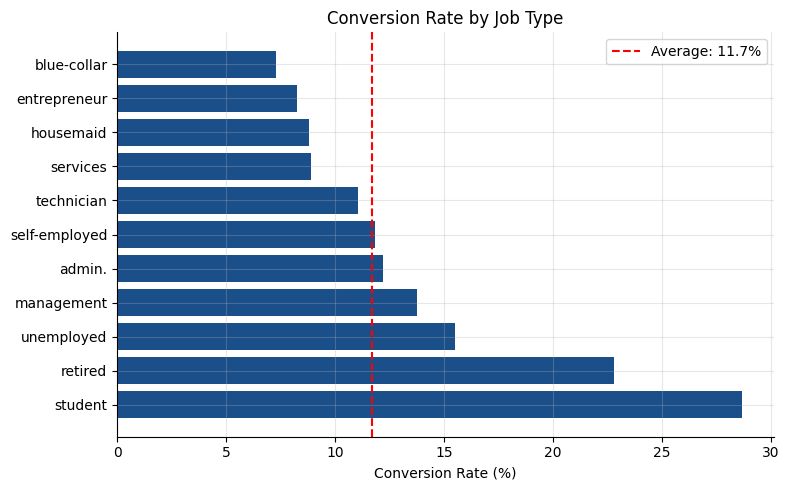

In [16]:
overall_rate = round(100.0 * df_clean['y_binary'].mean(), 2)

plt.figure(figsize=(8, 5))
plt.barh(job_conv['job'], job_conv['conv_rate'], color='#1B4F8A')
plt.axvline(overall_rate, color='red', linestyle='--', label=f'Average: {overall_rate}%')
plt.xlabel('Conversion Rate (%)')
plt.title('Conversion Rate by Job Type')
plt.legend()
plt.tight_layout()
plt.show()

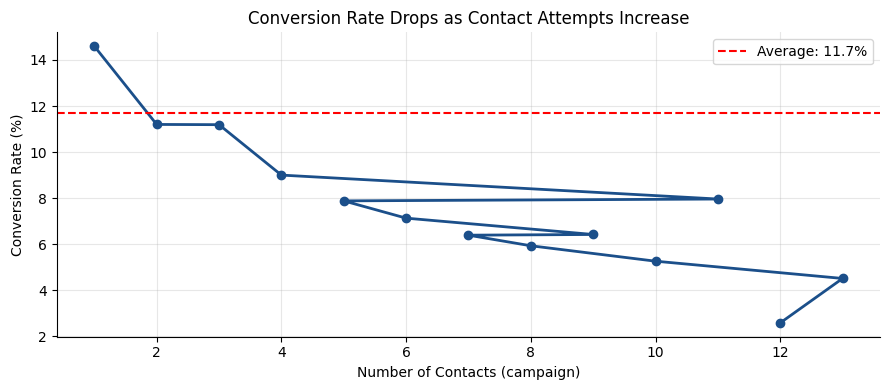

In [17]:
plt.figure(figsize=(9, 4))
plt.plot(campaign_count['campaign'], campaign_count['conv_rate'],
         marker='o', color='#1B4F8A', linewidth=2)
plt.axhline(overall_rate, color='red', linestyle='--', label=f'Average: {overall_rate}%')
plt.xlabel('Number of Contacts (campaign)')
plt.ylabel('Conversion Rate (%)')
plt.title('Conversion Rate Drops as Contact Attempts Increase')
plt.legend()
plt.tight_layout()
plt.show()

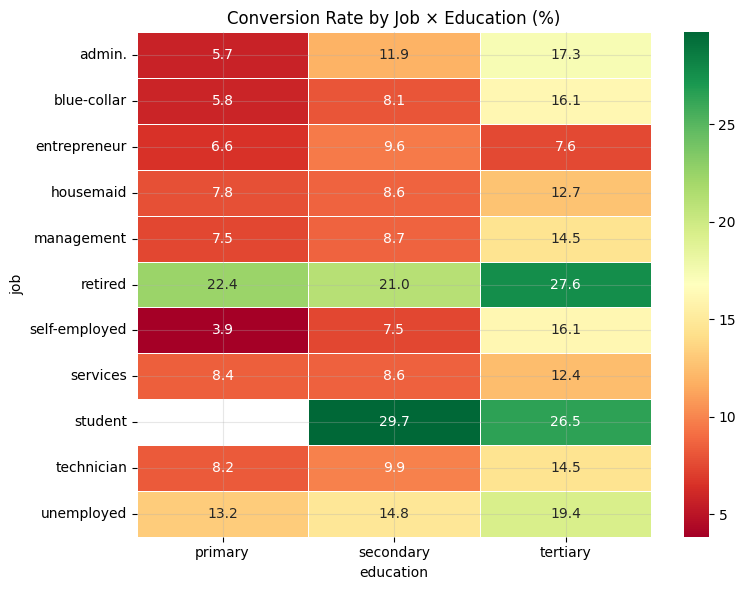

In [18]:
pivot = segment_by_education_job.pivot(index='job', columns='education', values='conv_rate')

plt.figure(figsize=(8, 6))
sns.heatmap(pivot, annot=True, fmt='.1f', cmap='RdYlGn', linewidths=0.5)
plt.title('Conversion Rate by Job × Education (%)')
plt.tight_layout()
plt.show()


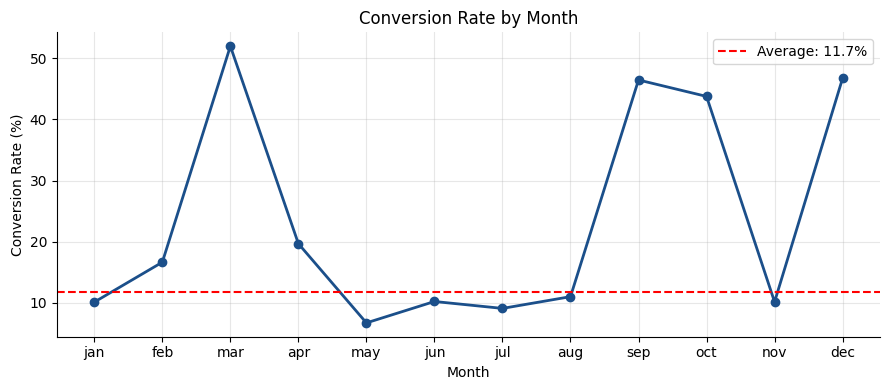

In [19]:
month_order = ['jan','feb','mar','apr','may','jun',
               'jul','aug','sep','oct','nov','dec']

month_conv['month'] = pd.Categorical(month_conv['month'],
                                      categories=month_order, ordered=True)
month_conv = month_conv.sort_values('month')

plt.figure(figsize=(9, 4))
plt.plot(month_conv['month'], month_conv['conv_rate'],
         marker='o', color='#1B4F8A', linewidth=2)
plt.axhline(overall_rate, color='red', linestyle='--', label=f'Average: {overall_rate}%')
plt.xlabel('Month')
plt.ylabel('Conversion Rate (%)')
plt.title('Conversion Rate by Month')
plt.legend()
plt.tight_layout()
plt.show()

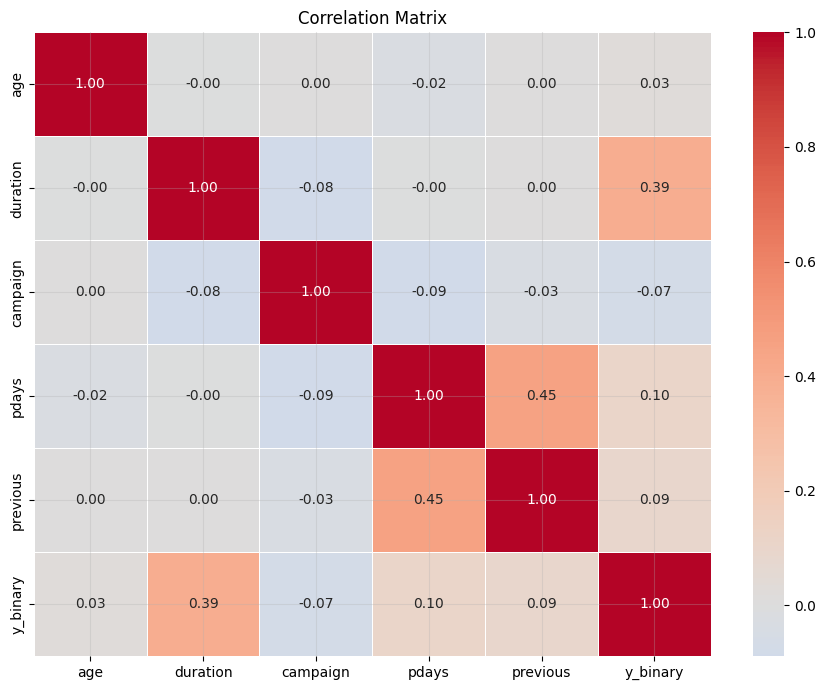

In [20]:
numeric_cols = ['age', 'duration', 'campaign','pdays','previous','y_binary']

corr = df_clean[numeric_cols].corr()

plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5)
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

In [21]:
X = pd.get_dummies(df.drop('y',axis=1))
y = (df['y']=='yes').astype(int)
Xtr,Xte,ytr,yte = train_test_split(X,y,test_size=.2,random_state=42)
clf = DecisionTreeClassifier(max_depth=5).fit(Xtr,ytr)
print(classification_report(yte, clf.predict(Xte)))

cm = confusion_matrix(yte, clf.predict(Xte))

print("CONFUSION MATRIX")
print(f"                  Predicted No   Predicted Yes")
print(f"Actual No         {cm[0][0]:>10,}   {cm[0][1]:>13,}")
print(f"Actual Yes        {cm[1][0]:>10,}   {cm[1][1]:>13,}")

tn, fp, fn, tp = cm.ravel()
print(f"\nTrue Negatives  (said No,  model said No):  {tn:,}")
print(f"True Positives  (said Yes, model said Yes): {tp:,}")
print(f"False Positives (said No,  model said Yes): {fp:,}  ← model was wrong")
print(f"False Negatives (said Yes, model said No):  {fn:,}  ← model missed them")

print(f"\nOf {1058} actual converters, model found: {tp} ({round(tp/1058*100,1)}%)")
print(f"Of {tp+fp} predicted converters, actually converted: {tp} ({round(tp/(tp+fp)*100,1)}%)")

              precision    recall  f1-score   support

           0       0.91      0.97      0.94      7952
           1       0.65      0.33      0.44      1091

    accuracy                           0.90      9043
   macro avg       0.78      0.65      0.69      9043
weighted avg       0.88      0.90      0.88      9043

CONFUSION MATRIX
                  Predicted No   Predicted Yes
Actual No              7,753             199
Actual Yes               729             362

True Negatives  (said No,  model said No):  7,753
True Positives  (said Yes, model said Yes): 362
False Positives (said No,  model said Yes): 199  ← model was wrong
False Negatives (said Yes, model said No):  729  ← model missed them

Of 1058 actual converters, model found: 362 (34.2%)
Of 561 predicted converters, actually converted: 362 (64.5%)


Top 5 features driving conversion:
         feature  importance
        duration    0.568743
poutcome_success    0.299172
             age    0.050240
       month_mar    0.039705
 contact_unknown    0.017555


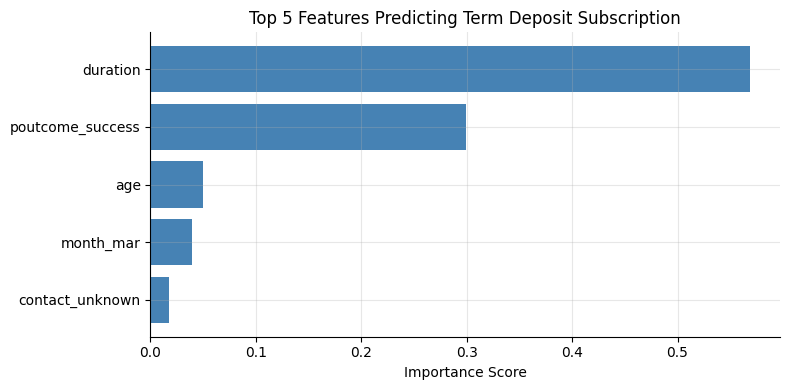

In [22]:
feature_names = X.columns.tolist()
importances   = clf.feature_importances_

importance_df = pd.DataFrame({
    'feature':    feature_names,
    'importance': importances
})

top5 = importance_df.sort_values('importance', ascending=False).head(5)

print("Top 5 features driving conversion:")
print(top5.to_string(index=False))

plt.figure(figsize=(8, 4))
plt.barh(top5['feature'], top5['importance'], color='steelblue')
plt.xlabel('Importance Score')
plt.title('Top 5 Features Predicting Term Deposit Subscription')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

**Validating model-identified drivers**

In [23]:
poutcome_conv = pd.read_sql("""
    SELECT poutcome,
        COUNT(*) as total_called,
        SUM(CASE WHEN y='yes' THEN 1 ELSE 0 END) as converted,
        ROUND(100.0 * SUM(CASE WHEN y='yes' THEN 1 ELSE 0 END) / COUNT(*), 2) as conv_rate
    FROM bank_calls
    GROUP BY poutcome
    ORDER BY conv_rate DESC
""", conn)
poutcome_conv

,poutcome,total_called,converted,conv_rate
0,success,1511,978,64.73
1,other,1840,307,16.68
2,failure,4901,618,12.61
3,unknown,36959,3386,9.16


In [24]:
duration_rate = pd.read_sql("""
SELECT
    CASE
        WHEN duration_min >= 0  AND duration_min <= 5 THEN '0-5_min'
        WHEN duration_min > 5  AND duration_min <= 10 THEN '5-10_min'
        WHEN duration_min > 10  AND duration_min <= 20 THEN '10-20_min'
        WHEN duration_min > 20  AND duration_min <= 30 THEN '20-30_min'
        WHEN duration_min > 30  AND duration_min <= 40 THEN '30-40_min'
        WHEN duration_min > 40  AND duration_min <= 50 THEN '40-50_min'
        WHEN duration_min > 50  AND duration_min <= 60 THEN '50-60_min'
        WHEN duration_min > 60                         THEN '60+_min'
        ELSE 'unknown'
    END as duration_bucket,
    COUNT(*) as total,
    ROUND(100.0 * SUM(CASE WHEN y='yes' THEN 1 ELSE 0 END) / COUNT(*), 2) as conv_rate
FROM bank_calls
GROUP BY duration_bucket;
""", conn)

duration_rate

,duration_bucket,total,conv_rate
0,0-5_min,32937,5.56
1,10-20_min,3230,46.04
2,20-30_min,453,64.24
3,30-40_min,78,50.00
4,40-50_min,15,66.67
5,5-10_min,8484,19.15
6,50-60_min,11,45.45
7,60+_min,3,33.33


In [27]:
pout_duration_rate_check = pd.read_sql("""SELECT
    poutcome,
    CASE
        WHEN duration_min <= 5 THEN 'under_5min'
        ELSE 'over_5min'
    END as duration_bucket,
    COUNT(*) as total,
    ROUND(100.0 * SUM(CASE WHEN y='yes' THEN 1 ELSE 0 END) / COUNT(*), 2) as conv_rate
FROM bank_calls
GROUP BY poutcome, duration_bucket
ORDER BY poutcome, duration_bucket;""", conn)
pout_duration_rate_check

,poutcome,duration_bucket,total,conv_rate
0,failure,over_5min,1224,29.58
1,failure,under_5min,3677,6.96
2,other,over_5min,520,34.81
3,other,under_5min,1320,9.55
4,success,over_5min,591,77.50
5,success,under_5min,920,56.52
6,unknown,over_5min,9939,24.72
7,unknown,under_5min,27020,3.44


In [26]:
conn = sqlite3.connect('bank_project.db')

# export the full clean dataset
df_powerbi = pd.read_sql("""
    SELECT
        job,
        education,
        marital,
        housing,
        loan,
        contact,
        month,
        duration,
        campaign,
        pdays,
        previous,
        poutcome,
        age,
        duration_min,
        y,
        y_binary,
        age_group,

        -- pre-calculate key metrics so Power BI can use them directly
        CASE WHEN y = 'yes' THEN 1 ELSE 0 END as converted,

        CASE
            WHEN campaign BETWEEN 1 AND 3 THEN 'Golden Window'
            WHEN campaign BETWEEN 4 AND 6 THEN 'Diminishing Returns'
            ELSE 'Wasted Effort'
        END as campaign_zone,

        CASE
            WHEN duration_min <= 5  THEN '1_0-5 min'
            WHEN duration_min <= 10 THEN '2_5-10 min'
            WHEN duration_min <= 20 THEN '3_10-20 min'
            ELSE '4_20+ min'
        END as duration_bucket,

        CASE
            WHEN month = 'jan' THEN 1
            WHEN month = 'feb' THEN 2
            WHEN month = 'mar' THEN 3
            WHEN month = 'apr' THEN 4
            WHEN month = 'may' THEN 5
            WHEN month = 'jun' THEN 6
            WHEN month = 'jul' THEN 7
            WHEN month = 'aug' THEN 8
            WHEN month = 'sep' THEN 9
            WHEN month = 'oct' THEN 10
            WHEN month = 'nov' THEN 11
            WHEN month = 'dec' THEN 12
            ELSE 0
        END as month_num

    FROM bank_calls
""", conn)

# save to CSV
#df_powerbi.to_csv('bank_powerbi.csv', index=False)
#print(f"Exported {len(df_powerbi):,} rows ✓")
#print(f"Columns: {df_powerbi.columns.tolist()}")

# download from Colab
#from google.colab import files
#files.download('bank_powerbi.csv')